In [1]:
!pip install polars

In [2]:
import polars as pl
import numpy as np

import matplotlib.pyplot as plt
import yaml
import torch
import torch.nn as nn
from torch.utils.data import Dataset, DataLoader, random_split

In [3]:
# data utils

import os
import pickle
import polars as pl
import numpy as np
from torch.utils.data import Dataset
import torch

def read_pkl(path: str) -> dict:
    with open(path, 'rb') as fo:
        d = pickle.load(fo, encoding='bytes')
    return d 

def make_df(path: str, metadata: dict) -> pl.DataFrame:
    d = read_pkl(path)
    img_data = [np.dstack([img[i: i + 1024].reshape((32, 32)) for i in range(0, len(img), 1024)]).astype(np.uint8) for img in d[b'data']]
    _data_dict = {
        "label": d[b'labels'],
        "label_names": [metadata[b'label_names'][l].decode("utf-8") for l in d[b'labels']]
    }
    _df = pl.DataFrame(_data_dict)
    _df = _df.with_columns(pl.Series("data", img_data, dtype=pl.Object))
    return _df


def make_df2(path: str, metadata: dict) -> pl.DataFrame:
    d = read_pkl(path)
    # _data_dict = {"data": val for i, val in enumerate(d[b'data'])}
    _data_dict ={}
    _data_dict["label"] = d[b'labels']
    _data_dict["data"] = d[b'data']
    _data_dict["label_names"] = [metadata[b'label_names'][l].decode("utf-8") for l in d[b'labels']]
    _df = pl.DataFrame(_data_dict)
    return _df

def read_data(path: str) -> tuple[pl.DataFrame]:
    meta = os.path.join(path, "batches.meta")
    train_pref = "data_batch_"
    test_pref = "test"
    
    files = os.listdir(path)
    
    metadata = read_pkl(meta)
    
    train_data = []
    test_data = []
    for file in files:
        if file.startswith(train_pref):
            train_data.append(make_df(os.path.join(path, file), metadata))
        elif file.startswith(test_pref):
            test_data.append(make_df(os.path.join(path, file), metadata))
    
    return pl.concat(train_data, how="vertical"), pl.concat(test_data, how="vertical")

def read_data_v2(path: str) -> tuple[pl.DataFrame]:
    meta = os.path.join(path, "batches.meta")
    train_pref = "data_batch_"
    test_pref = "test"
    
    files = os.listdir(path)
    
    metadata = read_pkl(meta)
    
    train_data = []
    test_data = []
    for file in files:
        if file.startswith(train_pref):
            train_data.append(make_df2(os.path.join(path, file), metadata))
        elif file.startswith(test_pref):
            test_data.append(make_df2(os.path.join(path, file), metadata))
    
    return pl.concat(train_data, how="vertical"), pl.concat(test_data, how="vertical")


class CIFARData(Dataset):
    def __init__(self, df: pl.DataFrame):
        super().__init__()
        self.df = df
    
    def __len__(self):
        return self.df.shape[0]
    
    def __getitem__(self, index):
        return {
            "data": torch.tensor(np.asarray(self.df[index]["data"].to_list()), dtype=torch.float32),
            "label": torch.tensor(np.asarray(self.df[index]["label"].to_list()), dtype=torch.long),
        }

def shift_data(val: list[int]):
    shift = 4
    size = 32
    
    new_data = []
    for i in range(0, len(val), size):
        new_data.extend((([0] * shift) + val[i : i + size])[:size])
    return new_data

In [4]:
# eval 

from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate(y_true, y_pred):
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred)

def format_cm(cm, *, 
              class_names: list[str] | None = None, 
              normalize: bool = False,
              normalize_axis: Literal[0, 1] = 1) -> pd.DataFrame:
    if not class_names:
        class_names = [f"class-{i}" for i in range(len(cm))]
    
    cm_df = pd.DataFrame(cm,
                         index=[f"True: {c}" for c in class_names],
                         columns=[f"Pred: {c}" for c in class_names]
                         )
    if not normalize:
        return cm_df
    
    cm_normalized = cm_df.div(cm_df.sum(axis=normalize_axis), axis= 0 if normalize_axis == 1 else 1)
    cm_normalized = cm_normalized.round(4)
    return cm_normalized

In [19]:
# network

import torch
import torch.nn as nn
import torchvision.models as ftmodels

class MobileNetv01(nn.Module):
    def __init__(self, n_classes: int = 10):
        super().__init__()
        
        self.base_model = ftmodels.mobilenet_v2(weights=None)
        
        self.head = nn.Sequential(
            nn.Dropout(0.2),
            
            nn.Linear(1280, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            
            nn.Linear(128, 128),
            nn.BatchNorm1d(128),
            nn.LeakyReLU(),
            
            nn.Linear(128, n_classes),
        )

        self.base_model.classifier = self.head
        
        for layer in self.head:
            if isinstance(layer, nn.Linear):
                nn.init.kaiming_uniform_(layer.weight)
                if layer.bias != None:
                    nn.init.zeros_(layer.bias)
        
    def forward(self, _input): # shape [batch, color, h, w]
        logit = self.base_model(_input)
        return logit

In [6]:
import os
PATH = "/kaggle/input/datasets/amallick0507/cifar10/cifar-10-batches-py"
comb_df, test_df = read_data_v2(PATH)

# with open("../configs/base_config.yaml", 'r') as f:
#     base_config = yaml.safe_load(f)

comb_df.shape, test_df.shape

meta = os.path.join(PATH, "batches.meta")

metadata = read_pkl(meta)
label_name = [l.decode("utf-8") for l in metadata[b'label_names']]

In [7]:
SEED = 15002
VAL_SPLIT = 0.2
GPU = 'cuda'
TRAIN_BATCH = 128
BATCH = 256

In [8]:
torch.manual_seed(SEED)
torch.backends.cudnn.deterministic = True
torch.backends.cudnn.benchmark = False

In [9]:

from sklearn.model_selection import train_test_split
X = comb_df["data"]; y = comb_df["label"]
X_test = test_df["data"]; y_test = test_df["label"]
X_train, X_val, y_train, y_val = train_test_split(X, y, 
                                                  test_size=VAL_SPLIT, 
                                                  random_state=SEED, 
                                                  stratify=y)


print("Train size: ", X_train.shape, y_train.shape)
print("Test size: ", X_test.shape, y_test.shape)
print("Val size: ", X_val.shape, y_val.shape)

Train size:  (40000,) (40000,)
Test size:  (10000,) (10000,)
Val size:  (10000,) (10000,)


In [10]:
train_df = pl.DataFrame({"data": X_train, "label": y_train})
val_df = pl.DataFrame({"data": X_val, "label": y_val})

train_df.shape, val_df.shape

((40000, 2), (10000, 2))

In [11]:
train_dataset = CIFARData(train_df)
test_dataset = CIFARData(test_df)
val_dataset = CIFARData(val_df)

train_loader = DataLoader(train_dataset, 
                         batch_size=TRAIN_BATCH, shuffle=True, num_workers=2)
val_loader = DataLoader(val_dataset, 
                       batch_size=BATCH, num_workers=2)
test_loader = DataLoader(test_dataset, 
                        batch_size=BATCH, num_workers=2)

In [12]:
from torchvision import transforms

train_tf = transforms.Compose([
    transforms.RandomCrop(32, padding=4),
    transforms.RandomHorizontalFlip(),
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

val_tf = transforms.Compose([
    transforms.Normalize((0.4914, 0.4822, 0.4465),
                         (0.2470, 0.2435, 0.2616)),
])

In [33]:
net = MobileNetv01(
    n_classes=len(y.unique())
).to(GPU)
optim = torch.optim.AdamW(net.parameters(), lr= 1e-3, weight_decay=1e-4)
criterion = nn.CrossEntropyLoss()
scheduler = torch.optim.lr_scheduler.CosineAnnealingLR(optim, T_max=100)

In [31]:
from sklearn.metrics import accuracy_score, f1_score
from tqdm import tqdm
def train(model: nn.Module,train_loader: DataLoader, 
          val_loader: DataLoader, epoch: int, 
          label_name: list[str], optimizer, criterion, scheduler, output_path = "mobilenet_v01.pth"):
    
    history = {
        "train_loss": [],
        "val_loss": [],
        "accuracy_score": [],
        "f1_score": []
    }

    best_f1 = 0.0
    no_improve = 0

    early_stopping_patience = 10
    
    for epoch in  tqdm(range(1,epoch + 1), total=epoch):
        y_val_pred = []
        y_val = []
        
        train_loss = 0.0
        
        model.train()
        for step, batch in enumerate(train_loader, 1):
            optimizer.zero_grad()
            
            _data = batch["data"]
            _label = batch["label"].to(GPU).reshape((-1))
            
            _data = _data.reshape((_data.shape[0], 3, 32, 32))
            _data = _data / 255.0
            _data = train_tf(_data)
            _data = _data.to(GPU)
            
            
            logit = model(_data)
            loss = criterion(logit, _label)
            
            loss.backward()
            optimizer.step()
            
            train_loss += loss
        train_loss = train_loss / len(train_loader)
        print(f"Training loss on epoch: {epoch}: {train_loss}")
        scheduler.step()
        
        val_loss = 0.0
        model.eval()
        with torch.no_grad():
            for step, batch in enumerate(val_loader, 1):
                _data = batch["data"]
                _label = batch["label"].to(GPU).reshape((-1))
                
                _data = _data.reshape((_data.shape[0], 3, 32, 32))
                _data = _data / 255.0
                _data = val_tf(_data)
                
                _data = _data.to(GPU)
                
                logit = model(_data)
                loss = criterion(logit, _label)
                
                val_loss += loss
                y_pred = logit.argmax(1)
                
                y_val.extend(_label.cpu().numpy())
                y_val_pred.extend(y_pred.cpu().numpy())
        val_loss = val_loss / len(val_loader)
        print(f"Val loss on epoch: {epoch}: {val_loss}")
        
        score = accuracy_score(y_val, y_val_pred)
        print(f"Val accuracy_score on epoch: {epoch}: {score}")
        f1 = f1_score(y_val, y_val_pred, average='macro')
        print(f"Val macro f1_score on epoch: {epoch}: {f1}")
        

        # Early stopping on minority F1
        if f1 > best_f1:
            best_f1 = f1
            no_improve = 0
            model_to_save = model.module if hasattr(model, "module") else model
            torch.save(model_to_save.state_dict(), output_path)
            print(f"Best model saved (macro F1={best_f1:.4f})")
        else:
            no_improve += 1
            print(f"No improvement ({no_improve}/{early_stopping_patience})")
            if no_improve >= early_stopping_patience:
                print(f"\nEarly stopping triggered at epoch {epoch}")
                break
        
        history["train_loss"].append(train_loss.detach().cpu().numpy())
        history["val_loss"].append(val_loss.detach().cpu().numpy())
        history["accuracy_score"].append(score)
        history["f1_score"].append(f1)

    return history

In [34]:
h1 = train(
    model = net,train_loader = train_loader, 
    val_loader = val_loader, epoch = 100, 
    label_name = label_name, optimizer = optim, 
    criterion = criterion, scheduler = scheduler
)

  0%|          | 0/100 [00:00<?, ?it/s]

Training loss on epoch: 1: 2.1677355766296387


  1%|          | 1/100 [00:11<19:18, 11.71s/it]

Val loss on epoch: 1: 2.0101873874664307
Val accuracy_score on epoch: 1: 0.2417
Val macro f1_score on epoch: 1: 0.21115288926351478
Best model saved (macro F1=0.2112)
Training loss on epoch: 2: 1.8978852033615112


  2%|▏         | 2/100 [00:23<19:19, 11.83s/it]

...

Val loss on epoch: 80: 0.6764786839485168
Val accuracy_score on epoch: 80: 0.7885
Val macro f1_score on epoch: 80: 0.7899334805783119
No improvement (8/10)
Training loss on epoch: 81: 0.31091535091400146


 81%|████████  | 81/100 [16:12<03:47, 11.99s/it]

Val loss on epoch: 81: 0.6724399924278259
Val accuracy_score on epoch: 81: 0.7889
Val macro f1_score on epoch: 81: 0.7898374750378531
No improvement (9/10)
Training loss on epoch: 82: 0.30562418699264526


 81%|████████  | 81/100 [16:24<03:50, 12.15s/it]

Val loss on epoch: 82: 0.6546459197998047
Val accuracy_score on epoch: 82: 0.7939
Val macro f1_score on epoch: 82: 0.7947041268322252
No improvement (10/10)

Early stopping triggered at epoch 82


In [35]:
import matplotlib.pyplot as plt

def plot_neural(epochs: int, train_loss: list, val_loss: list):

    plt.plot(
        range(epochs), train_loss, label='Training Loss', linewidth=2.0, color='blue', ls='dashed'
    )
    plt.plot(
        range(epochs), val_loss, label='Val Loss', linewidth=2.0, color='green', ls='solid'
    )
    plt.plot(
        range(epochs), [min(val_loss)]*epochs, label='Min Val Loss', linewidth=0.8, color='black', ls='dotted'
    )
    plt.legend()
    plt.xlabel("Epochs")
    plt.ylabel("Loss")
    plt.grid(axis='x')

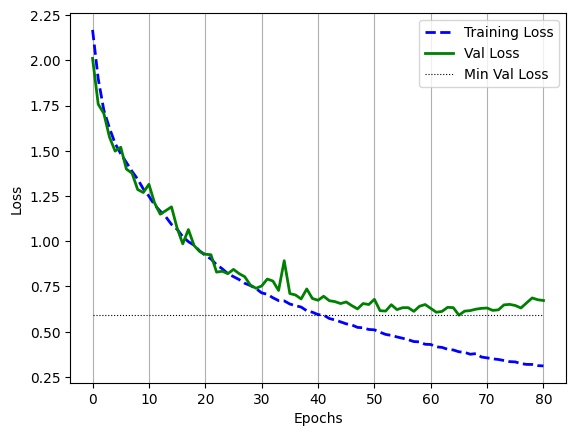

In [36]:
train_loss = h1["train_loss"]
val_loss = h1["val_loss"]
plot_neural(
    epochs= len(train_loss), train_loss= train_loss, val_loss = val_loss
)

In [40]:
net_best = MobileNetv01(
    n_classes=len(y.unique())
).to(GPU)

state_dict = torch.load('/kaggle/working/mobilenet_v01.pth', weights_only=True)

net_best.load_state_dict(state_dict)

<All keys matched successfully>

In [37]:
from typing import Literal
from sklearn.metrics import classification_report, confusion_matrix
import pandas as pd

def evaluate(y_true, y_pred):
    print(classification_report(y_true, y_pred, digits=4))
    return confusion_matrix(y_true, y_pred)

def format_cm(cm, *, 
              class_names: list[str] | None = None, 
              normalize: bool = False,
              normalize_axis: Literal[0, 1] = 1) -> pd.DataFrame:
    if not class_names:
        class_names = [f"class-{i}" for i in range(len(cm))]
    
    cm_df = pd.DataFrame(cm,
                         index=[f"True: {c}" for c in class_names],
                         columns=[f"Pred: {c}" for c in class_names]
                         )
    if not normalize:
        return cm_df
    
    cm_normalized = cm_df.div(cm_df.sum(axis=normalize_axis), axis= 0 if normalize_axis == 1 else 1)
    cm_normalized = cm_normalized.round(4)
    return cm_normalized

In [41]:
y_test_v = []
y_test_pred = []

net_best.eval()
with torch.no_grad():
    for step, batch in enumerate(test_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(GPU).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(GPU)
        
        logit = net_best(_data)
        y_pred = logit.argmax(1)
        
        y_test_v.extend(_label.cpu().numpy())
        y_test_pred.extend(y_pred.cpu().numpy())

cm = evaluate(y_test_v, y_test_pred)
format_cm(cm, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.7916    0.8470    0.8184      1000
           1     0.9074    0.9020    0.9047      1000
           2     0.7177    0.7170    0.7174      1000
           3     0.6304    0.6600    0.6448      1000
           4     0.7354    0.8060    0.7691      1000
           5     0.7087    0.6570    0.6819      1000
           6     0.7891    0.8570    0.8217      1000
           7     0.8786    0.8030    0.8391      1000
           8     0.8706    0.8810    0.8757      1000
           9     0.9392    0.8030    0.8658      1000

    accuracy                         0.7933     10000
   macro avg     0.7969    0.7933    0.7939     10000
weighted avg     0.7969    0.7933    0.7939     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.847,0.009,0.031,0.019,0.021,0.001,0.012,0.007,0.045,0.008
True: automobile,0.015,0.902,0.004,0.003,0.002,0.004,0.017,0.002,0.021,0.030
True: bird,0.053,0.002,0.717,0.047,0.070,0.042,0.049,0.011,0.009,0.000
True: cat,0.023,0.001,0.051,0.660,0.046,0.128,0.049,0.026,0.014,0.002
True: deer,0.011,0.002,0.048,0.038,0.806,0.022,0.047,0.021,0.005,0.000
True: dog,0.008,0.005,0.039,0.182,0.056,0.657,0.018,0.030,0.003,0.002
True: frog,0.007,0.000,0.044,0.047,0.020,0.017,0.857,0.004,0.004,0.000
True: horse,0.014,0.000,0.037,0.029,0.061,0.047,0.007,0.803,0.000,0.002
True: ship,0.058,0.014,0.013,0.010,0.007,0.002,0.006,0.001,0.881,0.008
True: truck,0.034,0.059,0.015,0.012,0.007,0.007,0.024,0.009,0.030,0.803


In [42]:
test_df_shifted = test_df.with_columns(pl.Series("data",[shift_data(data_list) for data_list in test_df["data"].to_list()] )) 
test_shifted_dataset = CIFARData(test_df_shifted)
test_shifted_loader = DataLoader(test_shifted_dataset, 
                       batch_size=BATCH, num_workers=2)

In [43]:
y_test_v_shifted = []
y_test_pred_shifted = []

net_best.eval()
with torch.no_grad():
    for step, batch in enumerate(test_shifted_loader, 1):
        _data = batch["data"]
        _label = batch["label"].to(GPU).reshape((-1))
        
        _data = _data.reshape((_data.shape[0], 3, 32, 32))
        _data = _data / 255.0
        _data = val_tf(_data)
        _data = _data.to(GPU)
        
        logit = net_best(_data)
        y_pred = logit.argmax(1)
        
        y_test_v_shifted.extend(_label.cpu().numpy())
        y_test_pred_shifted.extend(y_pred.cpu().numpy())

cm_shifted = evaluate(y_test_v_shifted, y_test_pred_shifted)
format_cm(cm_shifted, class_names=label_name, normalize=True)

              precision    recall  f1-score   support

           0     0.8119    0.7810    0.7961      1000
           1     0.9137    0.8470    0.8791      1000
           2     0.7156    0.7020    0.7087      1000
           3     0.5263    0.7000    0.6009      1000
           4     0.7260    0.8000    0.7612      1000
           5     0.6600    0.6640    0.6620      1000
           6     0.8190    0.7830    0.8006      1000
           7     0.8885    0.7170    0.7936      1000
           8     0.8656    0.8760    0.8708      1000
           9     0.8746    0.8020    0.8367      1000

    accuracy                         0.7672     10000
   macro avg     0.7801    0.7672    0.7710     10000
weighted avg     0.7801    0.7672    0.7710     10000



,Pred: airplane,Pred: automobile,Pred: bird,Pred: cat,Pred: deer,Pred: dog,Pred: frog,Pred: horse,Pred: ship,Pred: truck
True: airplane,0.781,0.011,0.051,0.030,0.022,0.003,0.019,0.008,0.052,0.023
True: automobile,0.024,0.847,0.001,0.012,0.001,0.007,0.013,0.005,0.025,0.065
True: bird,0.043,0.000,0.702,0.076,0.073,0.047,0.044,0.008,0.006,0.001
True: cat,0.014,0.002,0.041,0.700,0.043,0.129,0.041,0.020,0.010,0.000
True: deer,0.008,0.001,0.041,0.063,0.800,0.031,0.031,0.015,0.009,0.001
True: dog,0.006,0.001,0.039,0.218,0.041,0.664,0.007,0.020,0.003,0.001
True: frog,0.005,0.000,0.046,0.104,0.029,0.026,0.783,0.003,0.002,0.002
True: horse,0.009,0.000,0.038,0.064,0.083,0.079,0.004,0.717,0.001,0.005
True: ship,0.047,0.012,0.010,0.028,0.005,0.004,0.000,0.001,0.876,0.017
True: truck,0.025,0.053,0.012,0.035,0.005,0.016,0.014,0.010,0.028,0.802
